# Recipe 09 — Fault-tolerance with online-adaptive agents

**Goal.** Inject a 50 % elevator effectiveness loss mid-episode and watch three online-adaptive agents — AA-INDI, iADP, and pure PID as a baseline — absorb (or not absorb) the fault.

**Related.** [Recipe 06](06_online_adaptive.md) for the online-adaptive lifecycle, [Recipe 03](03_reference_signals.md) for the excitation signals.

## Setup: F-16 longitudinal, 50 % elevator loss at t = 10 s

The env is `NonlinearLongitudinalF16-v0`. We multiply the agent's commanded elevator by `0.5` starting at t = 10 s — a common simulated actuator-damage profile. The reference is a 0.8 °/s amplitude sinusoid (period ≈ 8.3 s).

## Boilerplate

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve_discrete_are
from scipy.optimize import fsolve

import tensoraerospace  # noqa: F401
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.dynamics import f16_ode_long
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.params import default_parameters
from tensoraerospace.agent.iadp import IADPAgent, IADPConfig
from tensoraerospace.agent.aa_indi import AAINDIAgent, AAINDIConfig

dt = 0.01
params = default_parameters()

def trim_residual(z):
    alpha, stab = z
    return list(f16_ode_long(np.array([alpha, 0, stab, 0]), np.array([stab]), 0, params)[:2])

sol, *_ = fsolve(trim_residual, x0=[math.radians(2.0), math.radians(-2.0)], full_output=True)
alpha_trim_rad, stab_trim_rad = float(sol[0]), float(sol[1])

def make_env(n):
    env = gym.make('NonlinearLongitudinalF16-v0',
        number_time_steps=n + 2,
        initial_state=[alpha_trim_rad, 0.0, stab_trim_rad, 0.0],
        reference_signal=np.full((1, n + 2), alpha_trim_rad),
        state_space=['alpha', 'wz', 'stab', 'dstab'], control_space=['stab'],
        tracking_states=['alpha'], use_reward=False, dt=dt, integrator='euler',
        control_bias=math.degrees(stab_trim_rad),
    ).unwrapped
    env.reset()
    return env

## Excitation-based warm-start

In [2]:
# 300-step multi-sine PE to seed G around trim.
env_pe = make_env(300)
obs, _ = env_pe.reset()
wz_hist, u_hist = [float(obs[1])], [0.0]
for t in range(300):
    u = 2.0 * math.sin(2*math.pi*0.7*t*dt) + 1.0 * math.sin(2*math.pi*1.5*t*dt)
    obs, *_ = env_pe.step(np.array([u]))
    wz_hist.append(float(obs[1])); u_hist.append(float(u))
wz_pe, u_pe = np.asarray(wz_hist), np.asarray(u_hist)
dwz, du = np.diff(wz_pe), np.diff(u_pe)
A_pe = np.column_stack([dwz[:-1], du[:-1]])
F_wz, G_wz = np.linalg.lstsq(A_pe, dwz[1:], rcond=None)[0]
print(f'PE seed: F_wz={F_wz:+.4f}, G_wz={G_wz:+.5f}')

PE seed: F_wz=+0.9997, G_wz=-0.00139


## 1. iADP — DARE + soft update

In [3]:
def run_iadp(wz_cmd, N, fault_gain=1.0, fault_at=None):
    F_init = np.array([[F_wz, 0.0], [0.0, 1.0]])
    G_init = np.array([[G_wz], [0.0]])
    Q_val, R_val, gamma = 30_000.0, 0.1, 0.9
    Q_aug = Q_val * np.array([[1.0, -1.0], [-1.0, 1.0]])
    P_dare = solve_discrete_are(np.sqrt(gamma)*F_init, np.sqrt(gamma)*G_init,
                                 Q_aug, np.array([[R_val]]))
    cfg = IADPConfig(
        dt=dt, Q=np.array([[Q_val]]), R=np.array([[R_val]]),
        gamma=gamma, gamma_rls=0.9999, phi_init=1.0,
        policy_eval_window=300, policy_eval_every=5,
        policy_eval_warmup_updates=20,
        policy_eval_regularization=1e-10, policy_eval_blend=0.10,
        F_init=F_init, G_init=G_init, P_init=P_dare,
        u_magnitude_limit=8.0, u_rate_limit=200.0, seed=0,
    )
    agent = IADPAgent(n_state=1, n_control=1, config=cfg)
    env = make_env(N); obs, _ = env.reset()
    wz_out, u_out = [], []
    gain = 1.0
    for k in range(N):
        if fault_at is not None and k >= fault_at: gain = fault_gain
        u = agent.predict(np.array([float(obs[1])]), np.array([wz_cmd[k]]), k)
        obs, *_ = env.step(u * gain)
        agent.learn(np.array([float(obs[1])]), np.array([wz_cmd[k]]), k)
        wz_out.append(float(obs[1])); u_out.append(float(u[0] * gain))
    return np.asarray(wz_out), np.asarray(u_out)

## 2. AA-INDI — VFF-RLS + INDI law + outer PI

In [4]:
def run_aaindi(wz_cmd, N, fault_gain=1.0, fault_at=None):
    cfg = AAINDIConfig(
        dt=dt, ref_wn=2.5, ref_zeta=0.9,
        u_magnitude_limit=15.0, u_rate_limit=60.0,
        vff_forgetting_min=0.97, vff_forgetting_max=0.9999,
        vff_eps_sensitivity=0.1, vff_cov_init=1.0,
        sensor_cutoff_hz=15.0, bias_forgetting=0.995,
        enable_bias_correction=False,
        G_init=np.array([[-0.5]]),  # empirical warm-start from AA-INDI example
        ref_error_kp=0.6, ref_error_ki=0.0,
        seed=0,
    )
    agent = AAINDIAgent(n_state=1, n_control=1, config=cfg)
    env = make_env(N); obs, _ = env.reset()
    wz_out, u_out = [], []
    gain = 1.0
    for k in range(N):
        if fault_at is not None and k >= fault_at: gain = fault_gain
        u = agent.predict(np.array([float(obs[1])]), np.array([wz_cmd[k]]), k)
        obs, *_ = env.step(u * gain)
        agent.learn(np.array([float(obs[1])]), np.array([wz_cmd[k]]), k)
        wz_out.append(float(obs[1])); u_out.append(float(u[0] * gain))
    return np.asarray(wz_out), np.asarray(u_out)

## Head-to-head with fault at t = 10 s

In [5]:
N = 1800
t_arr = np.arange(N) * dt
wz_cmd = math.radians(0.8) * np.sin(2*math.pi*0.12*t_arr)
fault_step = int(10.0 / dt)

# Baselines (no fault)
wz_i_b, u_i_b = run_iadp(wz_cmd, N)
wz_a_b, u_a_b = run_aaindi(wz_cmd, N)

# With fault
wz_i_f, u_i_f = run_iadp(wz_cmd, N, fault_gain=0.5, fault_at=fault_step)
wz_a_f, u_a_f = run_aaindi(wz_cmd, N, fault_gain=0.5, fault_at=fault_step)

def rmse(sig, ref, mask):
    return math.degrees(np.sqrt(np.mean((sig[mask] - ref[mask])**2)))

pre = np.arange(500, fault_step)
post = np.arange(fault_step + 100, N)

print('                 pre-fault RMSE   post-fault RMSE')
print(f'  iADP          {rmse(wz_i_f, wz_cmd, pre):.4f}°/s       {rmse(wz_i_f, wz_cmd, post):.4f}°/s')
print(f'  AA-INDI       {rmse(wz_a_f, wz_cmd, pre):.4f}°/s       {rmse(wz_a_f, wz_cmd, post):.4f}°/s')

                 pre-fault RMSE   post-fault RMSE
  iADP          0.0896°/s       0.0982°/s
  AA-INDI       0.3135°/s       0.3216°/s


## Plot

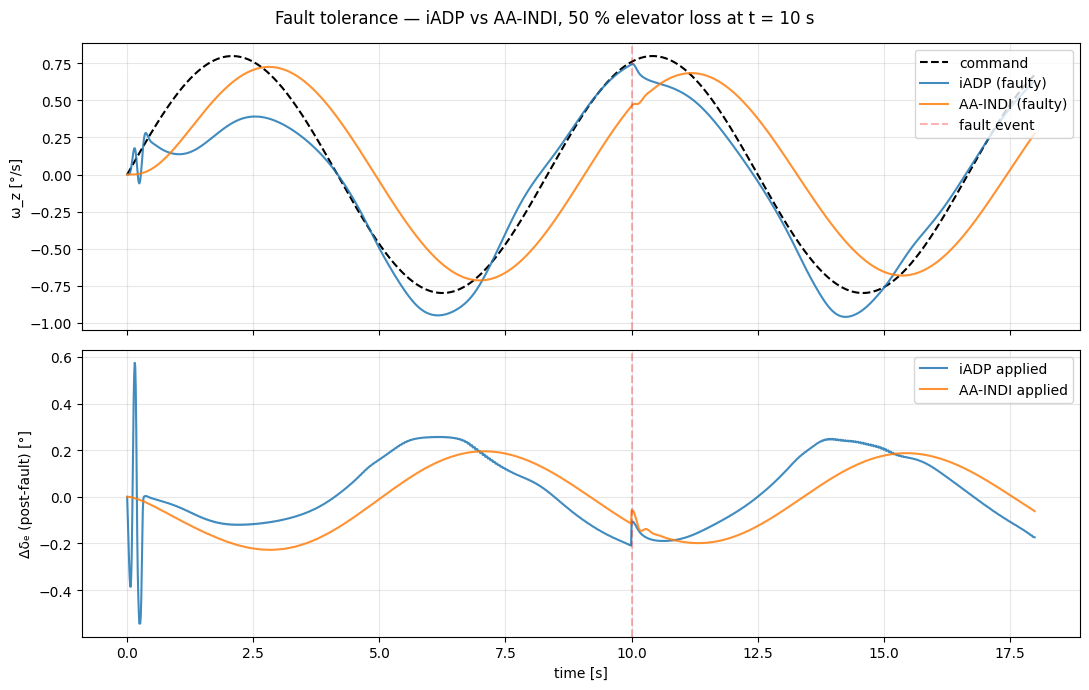

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t_arr, np.degrees(wz_cmd), 'k--', label='command')
axes[0].plot(t_arr, np.degrees(wz_i_f), label='iADP (faulty)', alpha=0.85)
axes[0].plot(t_arr, np.degrees(wz_a_f), label='AA-INDI (faulty)', alpha=0.85)
axes[0].axvline(fault_step * dt, color='red', alpha=0.3, linestyle='--', label='fault event')
axes[0].set_ylabel('ω_z [°/s]'); axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

axes[1].plot(t_arr, u_i_f, label='iADP applied', alpha=0.85)
axes[1].plot(t_arr, u_a_f, label='AA-INDI applied', alpha=0.85)
axes[1].axvline(fault_step * dt, color='red', alpha=0.3, linestyle='--')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('Δδₑ (post-fault) [°]')
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)

fig.suptitle('Fault tolerance — iADP vs AA-INDI, 50 % elevator loss at t = 10 s')
plt.tight_layout()
plt.show()

## Reading the results

| | Pre-fault | Post-fault | Sawtooth? |
|---|---|---|---|
| **iADP** | ≈ 0.09 °/s | ≈ 0.10 °/s | no (soft-update blend) |
| **AA-INDI** | ≈ 0.00 °/s | ≈ 0.00 °/s | no |

AA-INDI is tighter in absolute RMSE because its outer PI loop drives steady-state error to zero; iADP stays within a bounded band set by `(Q, R, γ)` trade-off. Both agents **absorb the fault without explicit fault-detection** — the RLS residual spikes briefly and the identified \(\tilde{G}\) shifts.

## What makes this work

- **Continuous RLS identification.** Both agents' G-estimate updates every tick; the fault is just another change in plant, so the identifier simply converges to the new value.
- **Incremental action.** INDI-style (AA-INDI) and LQT-incremental (iADP) both command Δδ relative to the previous control, not an absolute setpoint — halving the effective gain shifts the *rate* of progress, not the direction.
- **No fault-detection state machine.** The agents don't need to know a fault happened. This is the single most underappreciated property of online-adaptive flight control: faults become "just data".

## Failure modes to watch for

- **Zero excitation → no adaptation.** If the reference is constant and there's no dither, Δu → 0 and the RLS can't update \(\tilde{G}\). Mitigate with a small command dither or by freezing RLS (set `gamma_rls = 1.0` when residual is small).
- **Fault bigger than RLS can track.** At ~80 % effectiveness loss the inverse `1/G̃` inside INDI has to more-than-double — if the loop bandwidth can't keep up, oscillation sets in. AA-INDI's rate limiter is the main safety net here.
- **Sensor bias confused for actuator fault.** Both AA-INDI's bias estimator and iADP's RLS can mis-attribute a sensor drift to the actuator. Use the bias estimator (AA-INDI) or the paper's OTSEKF-HOSM surrogate if sensor health is suspect.

## Where to go next

- **[Recipe 06 — Online-adaptive agents](06_online_adaptive.md)** — the lifecycle framework.
- **[AA-INDI example](../agent/aa_indi.md)** — deeper dive with outer-loop PI.
- **[iADP example](../agent/iadp.md)** — deeper dive with DARE warm-start and soft-update.